# 1. Imports

In [133]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.base import clone
import seaborn as sns
import pandas as pd
import numpy as np
import random

from jmetal.operator.mutation import PolynomialMutation
from jmetal.operator.crossover import SBXCrossover
from jmetal.algorithm.multiobjective import NSGAII, SPEA2
from jmetal.core.solution import FloatSolution
from jmetal.util.termination_criterion import StoppingByEvaluations
from jmetal.util.solution import get_non_dominated_solutions
from jmetal.core.problem import Problem

# 2. Lecture de la base de données

In [134]:
df_diabetes = pd.read_csv("diabetes.csv")
df_yeast = pd.read_csv("yeast.csv")

# 3. Implémentation du Problème

In [135]:
class PartialClassificationProblem(Problem):
    def __init__(self, X, y):
        # Appeler le constructeur parent en premier
        super().__init__()
        
        self.X = np.array(X, dtype=float)
        self.y = np.array(y, dtype=int)
        self.n_attributes = self.X.shape[1]

        # Définition des bornes globales des attributs
        mins = X.min(axis=0)
        maxs = X.max(axis=0)

        self.lower_bound = []
        self.upper_bound = []

        for i in range(self.n_attributes):
            self.lower_bound.extend([mins[i], mins[i]])
            self.upper_bound.extend([maxs[i], maxs[i]])

    def number_of_variables(self) -> int:
        return 2 * self.n_attributes

    def number_of_objectives(self) -> int:
        return 3

    def number_of_constraints(self) -> int:
        return 0

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        variables = solution.variables
        y_pred = []

        for instance in self.X:
            rule_active = True

            for i in range(self.n_attributes):
                bi = variables[2 * i]
                bs = variables[2 * i + 1]

                # Attribut actif si bi <= bs
                if bi <= bs:
                    if not (bi <= instance[i] <= bs):
                        rule_active = False
                        break

            y_pred.append(1 if rule_active else 0)

        # Gestion cas sans prédictions positives
        if sum(y_pred) == 0:
            precision = 0.0
            recall = 0.0
            f1 = 0.0
        else:
            precision = precision_score(self.y, y_pred, zero_division=0)
            recall = recall_score(self.y, y_pred, zero_division=0)
            f1 = f1_score(self.y, y_pred, average='binary', zero_division=0)

        solution.objectives[0] = -precision
        solution.objectives[1] = -recall
        solution.objectives[2] = -f1
        return solution

    def create_solution(self) -> FloatSolution:
        solution = FloatSolution(
            self.lower_bound,
            self.upper_bound,
            self.number_of_objectives(),
            self.number_of_constraints()
        )

        solution.variables = [
            random.uniform(self.lower_bound[i], self.upper_bound[i])
            for i in range(self.number_of_variables())
        ]

        return solution

    def name(self):
        return "PartialClassificationProblem"

# 4. Algorithmes Connus

## 4.1. Pima Diabetes

In [136]:
zero_impossible_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_diabetes[zero_impossible_cols] = df_diabetes[zero_impossible_cols].replace(0, np.nan)
df_diabetes.fillna(df_diabetes.median(numeric_only=True), inplace=True)

X_diabetes = df_diabetes.drop('Outcome', axis=1)   # shape (768, 8)
y_diabetes= df_diabetes['Outcome']

X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes, y_diabetes,
    test_size=0.2,
    random_state=42,
    stratify=y_diabetes
)

# Important pour le SVM
scaler = StandardScaler()
X_train_diabetes_scaled = scaler.fit_transform(X_train_diabetes)
X_test_diabetes_scaled  = scaler.transform(X_test_diabetes)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

c45_model = DecisionTreeClassifier(
    criterion='entropy',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

model_configs = {
    "Random Forest": (rf_model, X_train_diabetes, X_test_diabetes),
    "SVM": (svm_model, X_train_diabetes_scaled, X_test_diabetes_scaled),
    "C4.5": (c45_model, X_train_diabetes, X_test_diabetes),
}

results_diabetes = {}

for name, (model, X_tr, X_te) in model_configs.items():
    # Entrainer
    model.fit(X_tr, y_train_diabetes)

    # Prevoir
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]   # probability of class 1

    # Valider
    cv_scores = cross_val_score(model, X_tr, y_train_diabetes, cv=5, scoring='accuracy')

    results_diabetes[name] = {
        "Accuracy": accuracy_score(y_test_diabetes, y_pred),
        "ROC AUC":  roc_auc_score(y_test_diabetes, y_prob),
        "CV Mean":  cv_scores.mean(),
        "CV Std":   cv_scores.std(),
        "y_pred":   y_pred,
        "y_prob":   y_prob,
        "model":    model
    }


## 4.2. Yeast

In [137]:
# Random Forest et SVM (boîtes noires) et C4.5 (boîte blanche).

zero_impossible_cols = ['Mit', 'Vac', 'Nuc']
df_yeast[zero_impossible_cols] = df_yeast[zero_impossible_cols].replace(0, np.nan)
df_yeast.fillna(df_yeast.median(numeric_only=True), inplace=True)

X_yeast = df_yeast.drop('Output', axis=1)   # shape (768, 8)
y_yeast= df_yeast['Output']

for col in df_yeast.select_dtypes(include='object').columns:
    if col != 'Output':                        # don't encode the target
        df_yeast[col] = LabelEncoder().fit_transform(df_yeast[col])

X_train_yeast, X_test_yeast, y_train_yeast, y_test_yeast = train_test_split(
    X_yeast, y_yeast,
    test_size=0.2,
    random_state=42,
    stratify=y_yeast
)

# Important pour le SVM
scaler = StandardScaler()
X_train_yeast_scaled = scaler.fit_transform(X_train_yeast)
X_test_yeast_scaled  = scaler.transform(X_test_yeast)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

c45_model = DecisionTreeClassifier(
    criterion='entropy',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

model_configs = {
    "Random Forest": (rf_model, X_train_yeast, X_test_yeast),
    "SVM": (svm_model, X_train_yeast_scaled, X_test_yeast_scaled),
    "C4.5": (c45_model, X_train_yeast, X_test_yeast),
}

results_yeast = {}

for name, (model, X_tr, X_te) in model_configs.items():
    model.fit(X_tr, y_train_yeast)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    cv_scores = cross_val_score(model, X_tr, y_train_yeast, cv=5, scoring='accuracy')

    results_yeast[name] = {
        "Accuracy": accuracy_score(y_test_yeast, y_pred),
        "ROC AUC":  roc_auc_score(y_test_yeast, y_prob),
        "CV Mean":  cv_scores.mean(),
        "CV Std":   cv_scores.std(),
        "y_pred":   y_pred,
        "y_prob":   y_prob,
        "model":    model
    }

# 5. Algorithmes Génétiques

In [138]:
def run_algorithm(algorithm_class, problem, population_size, max_evaluations,
                  crossover_prob=0.9, mutation_prob=None):

    n_vars = problem.number_of_variables()

    if mutation_prob is None:
        mutation_prob = 1.0 / n_vars

    crossover = SBXCrossover(probability=crossover_prob, distribution_index=20)
    mutation  = PolynomialMutation(probability=mutation_prob, distribution_index=20)

    # StoppingByEvaluations parameter differs by version — try both
    try:
        termination = StoppingByEvaluations(max_evaluations=max_evaluations)
    except TypeError:
        termination = StoppingByEvaluations(max=max_evaluations)

    algorithm = algorithm_class(
        problem=problem,
        population_size=population_size,
        offspring_population_size=population_size,
        mutation=mutation,
        crossover=crossover,
        termination_criterion=termination
    )

    print(f"  Running {algorithm.get_name()} — {max_evaluations} evaluations...")
    algorithm.run()

    try:
        raw_results = algorithm.result()
    except AttributeError:
        raw_results = algorithm.get_result()

    pareto_front = get_non_dominated_solutions(raw_results)
    print(f"  Done. Pareto front size: {len(pareto_front)}")
    return pareto_front, algorithm


In [139]:
POPULATION_SIZE  = 100
MAX_EVALUATIONS  = 2000

datasets = {
    "Diabetes": (X_train_diabetes, y_train_diabetes),
    "Yeast":    (X_train_yeast,    y_train_yeast),
}

algorithms = {
    "NSGA-II": NSGAII,
    "SPEA2":   SPEA2,
}

all_results = {}

for dataset_name, (X, y) in datasets.items():
    all_results[dataset_name] = {}
    print(f"\n{'='*50}")
    print(f"  Dataset: {dataset_name}")
    print(f"{'='*50}")

    problem = PartialClassificationProblem(X, y)

    for algo_name, algo_class in algorithms.items():
        pareto_front, _ = run_algorithm(
            algo_class, problem,
            population_size=POPULATION_SIZE,
            max_evaluations=MAX_EVALUATIONS
        )
        all_results[dataset_name][algo_name] = pareto_front

/var/folders/6h/cnk0w1p91298chyy37whjgfr0000gn/T/ipykernel_34131/3115922558.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.lower_bound.extend([mins[i], mins[i]])
/var/folders/6h/cnk0w1p91298chyy37whjgfr0000gn/T/ipykernel_34131/3115922558.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.upper_bound.extend([maxs[i], maxs[i]])
[2026-03-21 11:49:12,792] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-21 11:49:12,793] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-21 11:49:12,902] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-21 11:49:


  Dataset: Diabetes
  Running NSGAII — 2000 evaluations...


[2026-03-21 11:49:17,158] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-21 11:49:17,160] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-21 11:49:17,161] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-21 11:49:17,266] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-21 11:49:17,267] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met


  Done. Pareto front size: 51
  Running SPEA2 — 2000 evaluations...


[2026-03-21 11:49:21,834] [jmetal.core.algorithm] [DEBUG] Finished!
/var/folders/6h/cnk0w1p91298chyy37whjgfr0000gn/T/ipykernel_34131/3115922558.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.lower_bound.extend([mins[i], mins[i]])
/var/folders/6h/cnk0w1p91298chyy37whjgfr0000gn/T/ipykernel_34131/3115922558.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.upper_bound.extend([maxs[i], maxs[i]])
[2026-03-21 11:49:21,837] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-21 11:49:21,837] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-21 11:49:21,917] [jmetal

  Done. Pareto front size: 42

  Dataset: Yeast
  Running NSGAII — 2000 evaluations...


[2026-03-21 11:49:27,241] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-21 11:49:27,243] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-21 11:49:27,244] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-21 11:49:27,345] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-21 11:49:27,345] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met


  Done. Pareto front size: 60
  Running SPEA2 — 2000 evaluations...


[2026-03-21 11:49:33,134] [jmetal.core.algorithm] [DEBUG] Finished!


  Done. Pareto front size: 55


In [140]:
# GÉNÉRÉ PAR L'IA

def pareto_to_dataframe(pareto_front, dataset_name, algo_name):
    rows = []
    for sol in pareto_front:
        rows.append({
            "Dataset":   dataset_name,
            "Algorithm": algo_name,
            "Precision": -sol.objectives[0],
            "Recall":    -sol.objectives[1],
            "F1":        -sol.objectives[2],
        })
    return pd.DataFrame(rows)

dfs = []
for dataset_name, algo_dict in all_results.items():
    for algo_name, pareto_front in algo_dict.items():
        dfs.append(pareto_to_dataframe(pareto_front, dataset_name, algo_name))

df_results = pd.concat(dfs, ignore_index=True)

summary = (df_results
           .groupby(["Dataset", "Algorithm"])
           .agg(
               Best_F1=("F1", "max"),
               Mean_F1=("F1", "mean"),
               Best_Precision=("Precision", "max"),
               Best_Recall=("Recall", "max"),
               Pareto_Size=("F1", "count")
           )
           .reset_index())

summary

,Dataset,Algorithm,Best_F1,Mean_F1,Best_Precision,Best_Recall,Pareto_Size
0,Diabetes,NSGA-II,0.636752,0.536500,1.0,1.0,51
1,Diabetes,SPEA2,0.642082,0.568736,1.0,1.0,42
2,Yeast,NSGA-II,0.591353,0.458820,1.0,1.0,60
3,Yeast,SPEA2,0.589309,0.433221,1.0,1.0,55


# 6. Comparaison des Algorithmes

## 6.1. Algorithmes Baseline

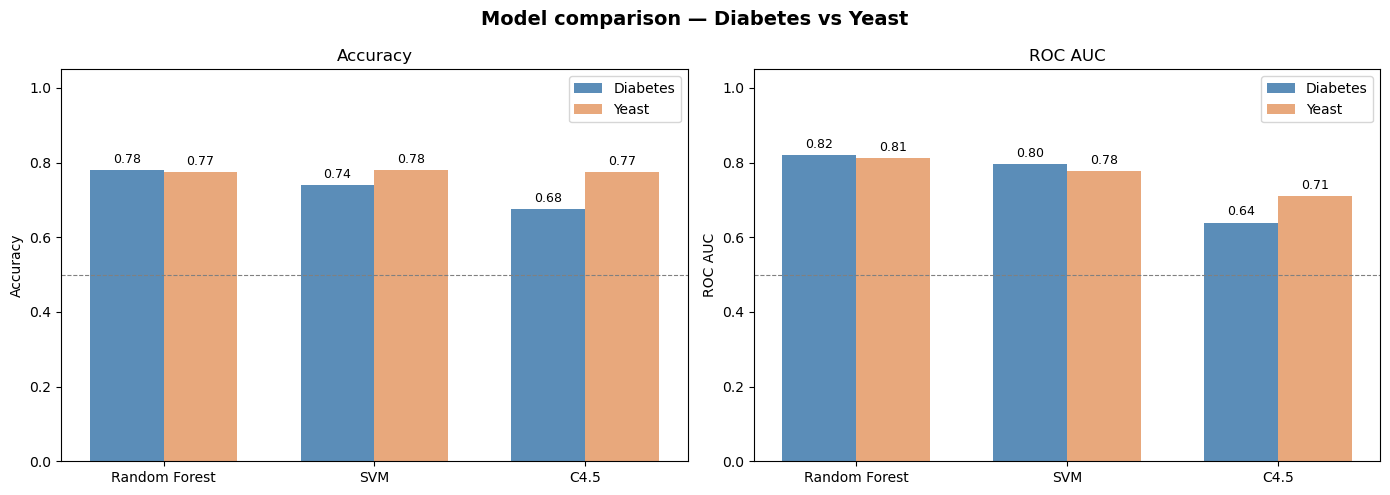

In [141]:
# GÉNÉRÉ PAR L'IA
datasets = {
    "Diabetes": results_diabetes,
    "Yeast":    results_yeast
}

metrics   = ["Accuracy", "ROC AUC"]
model_names = ["Random Forest", "SVM", "C4.5"]
x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model comparison — Diabetes vs Yeast", fontsize=14, fontweight='bold')

for ax, metric in zip(axes, metrics):
    bars_diabetes = [results_diabetes[m][metric] for m in model_names]
    bars_yeast    = [results_yeast[m][metric]    for m in model_names]

    ax.bar(x - width/2, bars_diabetes, width, label="Diabetes", color="#5B8DB8")
    ax.bar(x + width/2, bars_yeast,    width, label="Yeast",    color="#E8A87C")

    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.legend()
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline')

    # Add value labels on top of each bar
    for bar in ax.patches:
        ax.annotate(f"{bar.get_height():.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("comparison_metrics.png", dpi=150)
plt.show()

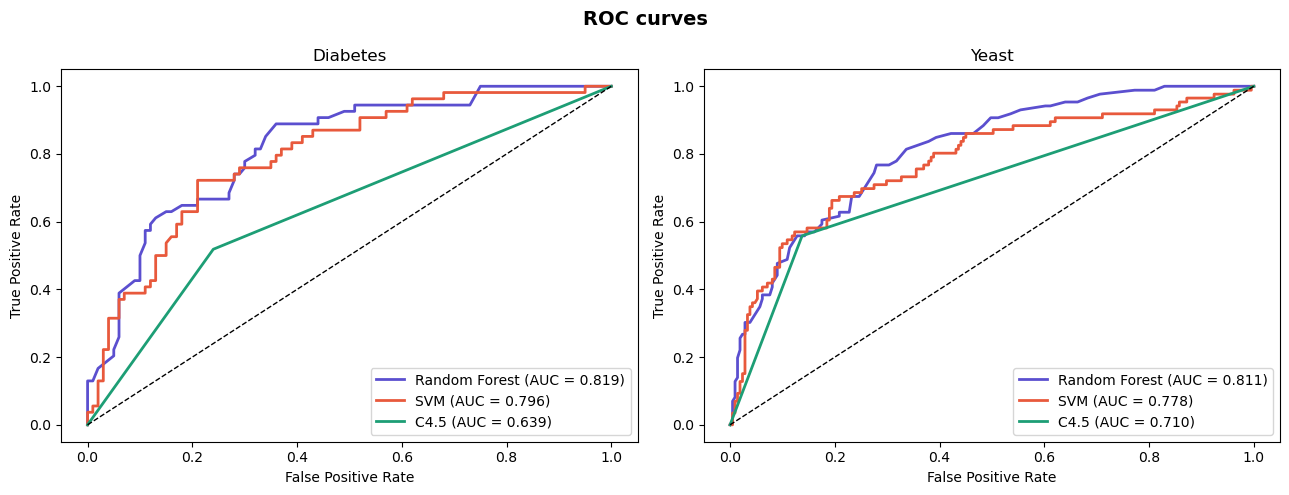

In [142]:
# GÉNÉRÉ PAR L'IA
from sklearn.metrics import roc_curve

colors = {"Random Forest": "#5B4FCF", "SVM": "#E8593C", "C4.5": "#1D9E75"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ROC curves", fontsize=14, fontweight='bold')

for ax, (dataset_name, results) in zip(axes, datasets.items()):
    for model_name, res in results.items():
        fpr, tpr, _ = roc_curve(
            y_test_diabetes if dataset_name == "Diabetes" else y_test_yeast,
            res['y_prob']
        )
        ax.plot(fpr, tpr, lw=2, color=colors[model_name],
                label=f"{model_name} (AUC = {res['ROC AUC']:.3f})")

    ax.plot([0,1], [0,1], 'k--', lw=1)
    ax.set_title(dataset_name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig("roc_curves_comparison.png", dpi=150)
plt.show()

## 6.2. Algorithmes Génétiques

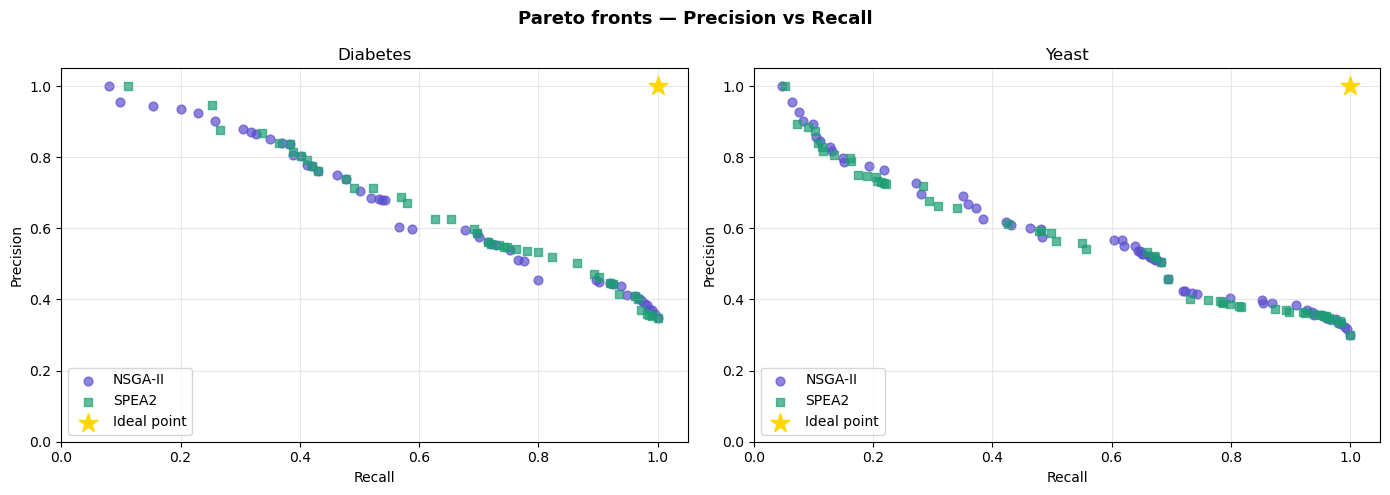

In [143]:
# GÉNÉRÉ PAR L'IA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pareto fronts — Precision vs Recall", fontsize=13, fontweight='bold')

colors = {"NSGA-II": "#5B4FCF", "SPEA2": "#1D9E75"}
markers = {"NSGA-II": "o", "SPEA2": "s"}

for ax, dataset_name in zip(axes, ["Diabetes", "Yeast"]):
    for algo_name in ["NSGA-II", "SPEA2"]:
        subset = df_results[
            (df_results["Dataset"] == dataset_name) &
            (df_results["Algorithm"] == algo_name)
        ]
        ax.scatter(subset["Recall"], subset["Precision"],
                   label=algo_name, alpha=0.7, s=40,
                   color=colors[algo_name],
                   marker=markers[algo_name])

    ax.set_title(dataset_name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    # Ideal point marker
    ax.scatter([1], [1], marker='*', s=200, color='gold',
               zorder=5, label='Ideal point')
    ax.legend()

plt.tight_layout()
plt.savefig("pareto_fronts.png", dpi=150)
plt.show()


/var/folders/6h/cnk0w1p91298chyy37whjgfr0000gn/T/ipykernel_34131/2535082074.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="Algorithm", y="F1", ax=ax,
/var/folders/6h/cnk0w1p91298chyy37whjgfr0000gn/T/ipykernel_34131/2535082074.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="Algorithm", y="F1", ax=ax,


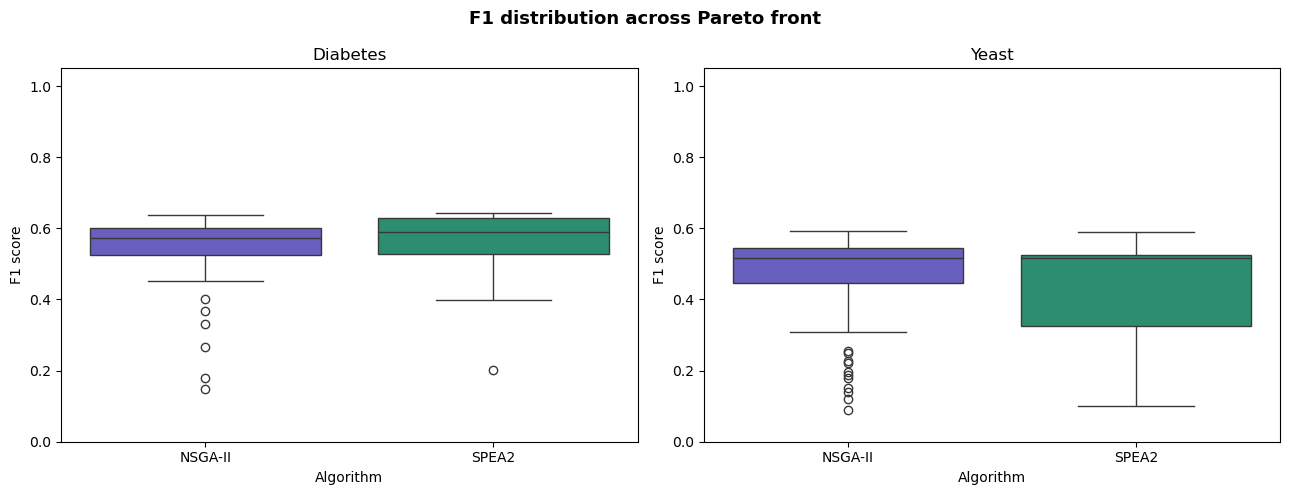

In [144]:
# GÉNÉRÉ PAR L'IA
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("F1 distribution across Pareto front", fontsize=13, fontweight='bold')

for ax, dataset_name in zip(axes, ["Diabetes", "Yeast"]):
    subset = df_results[df_results["Dataset"] == dataset_name]
    sns.boxplot(data=subset, x="Algorithm", y="F1", ax=ax,
                palette={"NSGA-II": "#5B4FCF", "SPEA2": "#1D9E75"})
    ax.set_title(dataset_name)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1 score")

plt.tight_layout()
plt.savefig("f1_boxplot.png", dpi=150)
plt.show()

# 7. Analyse des Résultats

In [149]:
# GÉNÉRÉ PAR L'IA

# ── Sklearn results (already computed) ───────────────────────────────────
rows = []

for dataset_name, (results, y_test) in {
    "Diabetes": (results_diabetes, y_test_diabetes),
    "Yeast":    (results_yeast,    y_test_yeast)
}.items():
    for model_name, res in results.items():
        rows.append({
            "Dataset":    dataset_name,
            "Algorithm":  model_name,
            "Type":       "Black-box" if model_name in ["Random Forest", "SVM"] else "White-box",
            "Family":     "Sklearn",
            "Accuracy":   res["Accuracy"],
            "ROC AUC":    res["ROC AUC"],
            "CV Mean":    res["CV Mean"],
            "CV Std":     res["CV Std"],
            "F1":         None,   # filled below for consistency
            "Precision":  None,
            "Recall":     None,
        })

# ── jMetalPy results — extract best-F1 solution per algorithm ────────────
for dataset_name, algo_dict in all_results.items():
    y_test = y_test_diabetes if dataset_name == "Diabetes" else y_test_yeast

    for algo_name, pareto_front in algo_dict.items():
        # Best solution = highest F1 on the Pareto front
        best = max(pareto_front, key=lambda s: -s.objectives[2])

        rows.append({
            "Dataset":    dataset_name,
            "Algorithm":  algo_name,
            "Type":       "Evolutionary",
            "Family":     "jMetalPy",
            "Accuracy":   None,
            "ROC AUC":    None,
            "CV Mean":    None,
            "CV Std":     None,
            "F1":        -best.objectives[2],
            "Precision": -best.objectives[0],
            "Recall":    -best.objectives[1],
        })

# Also compute F1/Precision/Recall for sklearn models so bars are comparable
from sklearn.metrics import precision_score, recall_score, f1_score

for row in rows:
    if row["Family"] == "Sklearn":
        ds   = row["Dataset"]
        name = row["Algorithm"]
        res  = results_diabetes[name] if ds == "Diabetes" else results_yeast[name]
        y_t  = y_test_diabetes if ds == "Diabetes" else y_test_yeast
        row["F1"]        = f1_score(y_t, res["y_pred"], average='binary', zero_division=0)
        row["Precision"] = precision_score(y_t, res["y_pred"], zero_division=0)
        row["Recall"]    = recall_score(y_t, res["y_pred"], zero_division=0)

df_all = pd.DataFrame(rows)
print(df_all[["Dataset", "Algorithm", "Type", "F1", "Precision", "Recall", "ROC AUC"]].to_string(index=False))

for row in rows:
    if row["Family"] == "Sklearn":
        ds   = row["Dataset"]
        name = row["Algorithm"]
        res  = results_diabetes[name] if ds == "Diabetes" else results_yeast[name]
        y_t  = y_test_diabetes if ds == "Diabetes" else y_test_yeast
        row["F1"]        = f1_score(y_t, res["y_pred"], average='binary', zero_division=0)
        row["Precision"] = precision_score(y_t, res["y_pred"], zero_division=0)
        row["Recall"]    = recall_score(y_t, res["y_pred"], zero_division=0)

df_all = pd.DataFrame(rows)
print(df_all[["Dataset", "Algorithm", "Type", "F1", "Precision", "Recall", "ROC AUC"]].to_string(index=False))


 Dataset     Algorithm         Type       F1  Precision   Recall  ROC AUC
Diabetes Random Forest    Black-box 0.653061   0.727273 0.592593 0.819167
Diabetes           SVM    Black-box 0.600000   0.652174 0.555556 0.796389
Diabetes          C4.5    White-box 0.528302   0.538462 0.518519 0.639259
   Yeast Random Forest    Black-box 0.531469   0.666667 0.441860 0.811418
   Yeast           SVM    Black-box 0.496124   0.744186 0.372093 0.778436
   Yeast          C4.5    White-box 0.588957   0.623377 0.558140 0.710349
Diabetes       NSGA-II Evolutionary 0.636752   0.586614 0.696262      NaN
Diabetes         SPEA2 Evolutionary 0.642082   0.599190 0.691589      NaN
   Yeast       NSGA-II Evolutionary 0.591353   0.566845 0.618076      NaN
   Yeast         SPEA2 Evolutionary 0.589309   0.533019 0.658892      NaN
 Dataset     Algorithm         Type       F1  Precision   Recall  ROC AUC
Diabetes Random Forest    Black-box 0.653061   0.727273 0.592593 0.819167
Diabetes           SVM    Black-box 0.

In [152]:
# GÉNÉRÉ PAR L'IA
COLORS = {
    "Random Forest": "#5B4FCF",
    "SVM":           "#E8593C",
    "C4.5":          "#1D9E75",
    "NSGA-II":       "#E8A82A",
    "SPEA2":         "#3B8BD4",
}

ALGO_ORDER = ["Random Forest", "SVM", "C4.5", "NSGA-II", "SPEA2"]
DATASETS   = ["Diabetes", "Yeast"]

/var/folders/6h/cnk0w1p91298chyy37whjgfr0000gn/T/ipykernel_34131/4154841288.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ALGO_ORDER, rotation=30, ha='right', fontsize=8)
/var/folders/6h/cnk0w1p91298chyy37whjgfr0000gn/T/ipykernel_34131/4154841288.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ALGO_ORDER, rotation=30, ha='right', fontsize=8)
/var/folders/6h/cnk0w1p91298chyy37whjgfr0000gn/T/ipykernel_34131/4154841288.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ALGO_ORDER, rotation=30, ha='right', fontsize=8)
/var/folders/6h/cnk0w1p91298chyy37whjgfr0000gn/T/ipykernel_34131/4154841288.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of t

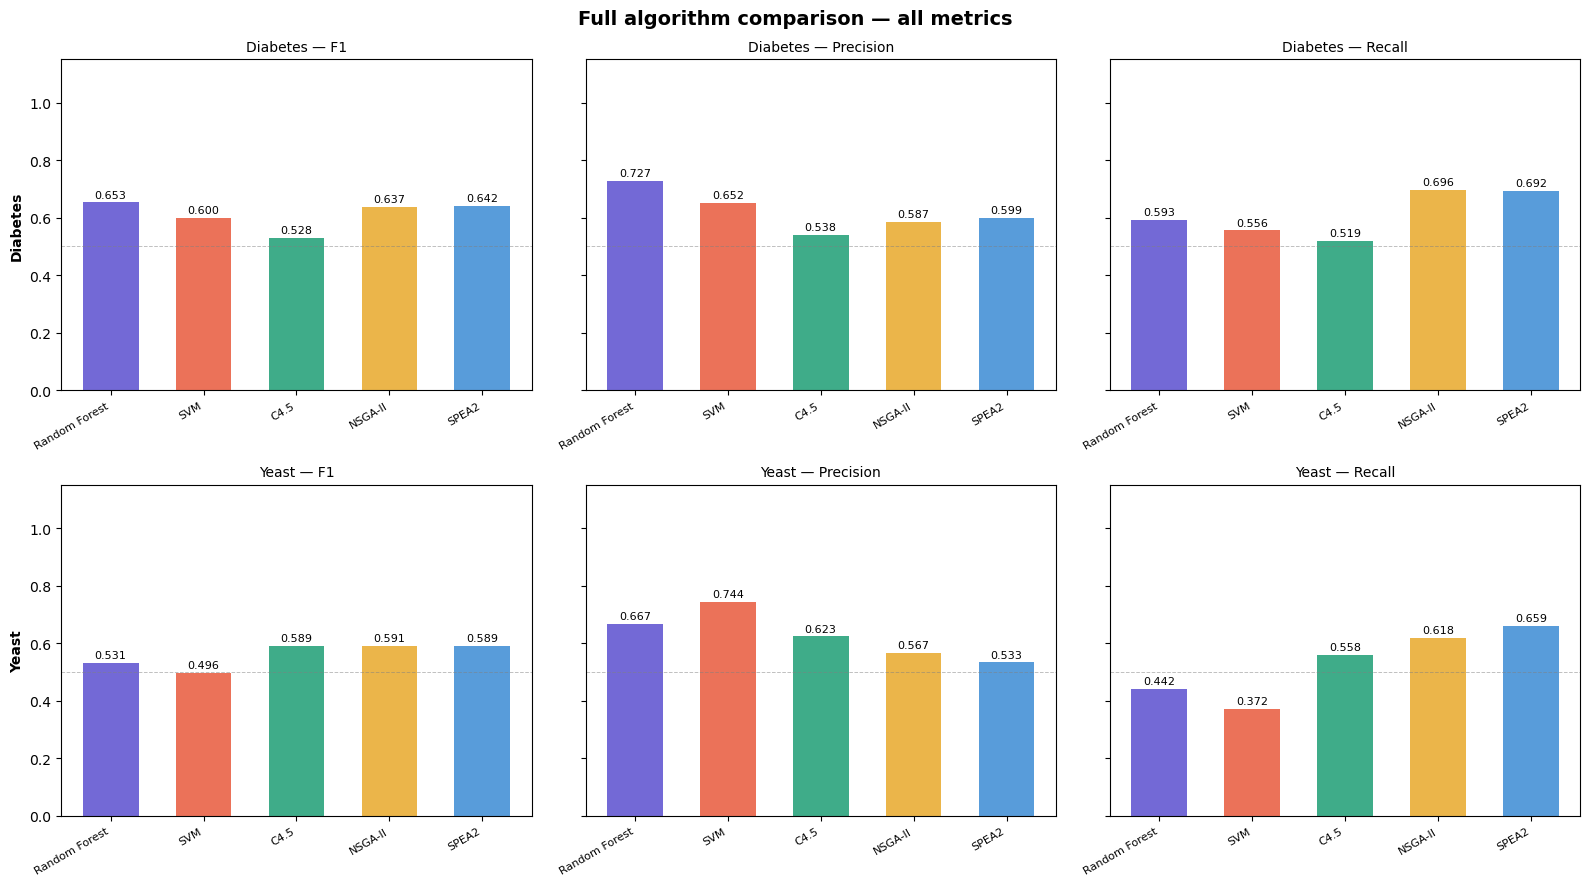

In [153]:
# GÉNÉRÉ PAR L'IA
metrics = ["F1", "Precision", "Recall"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
fig.suptitle("Full algorithm comparison — all metrics", fontsize=14, fontweight='bold')

for row, dataset in enumerate(DATASETS):
    for col, metric in enumerate(metrics):
        ax     = axes[row][col]
        subset = df_all[df_all["Dataset"] == dataset].set_index("Algorithm")

        values = [subset.loc[a, metric] if a in subset.index else 0
                  for a in ALGO_ORDER]
        colors = [COLORS[a] for a in ALGO_ORDER]

        bars = ax.bar(ALGO_ORDER, values, color=colors, alpha=0.85, width=0.6)

        # Value labels
        for bar, val in zip(bars, values):
            if val is not None and not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.01,
                        f"{val:.3f}", ha='center', va='bottom', fontsize=8)

        ax.set_title(f"{dataset} — {metric}", fontsize=10)
        ax.set_ylim(0, 1.15)
        ax.set_xticklabels(ALGO_ORDER, rotation=30, ha='right', fontsize=8)
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)

        if col == 0:
            ax.set_ylabel(dataset, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("master_comparison.png", dpi=150)
plt.show()

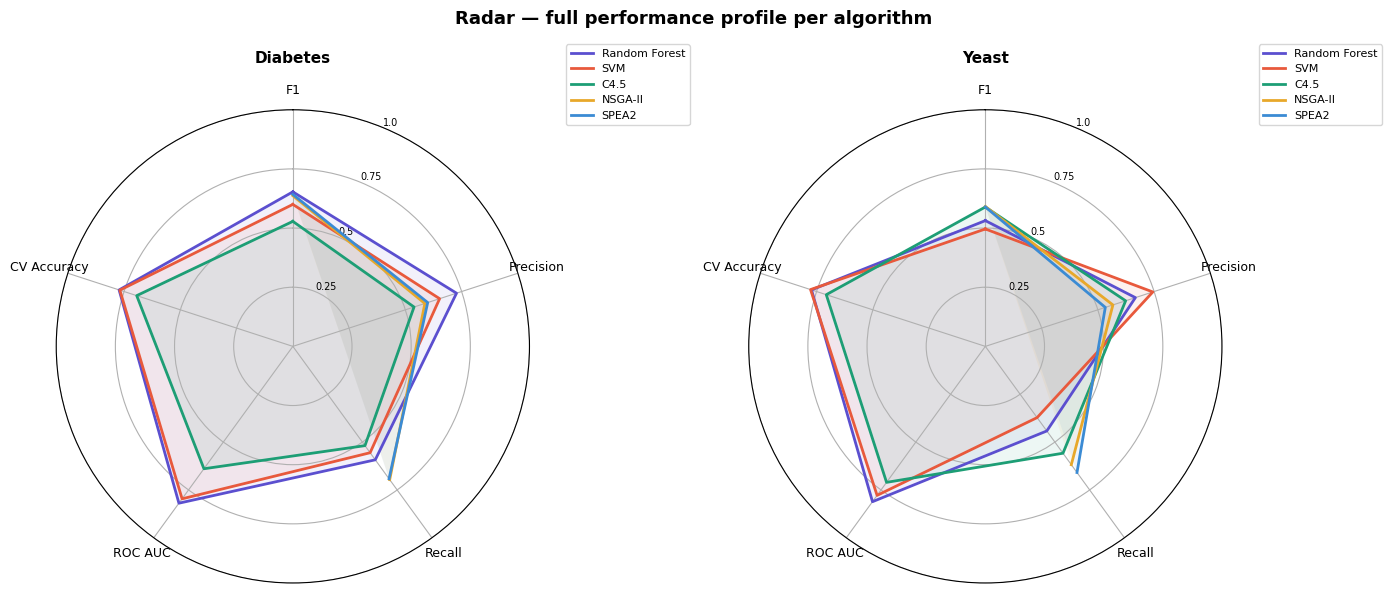

In [154]:
# GÉNÉRÉ PAR L'IA
from matplotlib.patches import FancyArrowPatch

def radar_chart(ax, values_dict, categories, title):
    N      = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]   # close the loop

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=7)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=15)

    for algo, vals in values_dict.items():
        v = vals + vals[:1]
        ax.plot(angles, v, color=COLORS[algo], linewidth=2, label=algo)
        ax.fill(angles, v, color=COLORS[algo], alpha=0.08)

    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)


categories = ["F1", "Precision", "Recall", "ROC AUC", "CV Accuracy"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw=dict(polar=True))
fig.suptitle("Radar — full performance profile per algorithm", fontsize=13, fontweight='bold')

for ax, dataset in zip(axes, DATASETS):
    values_dict = {}
    subset = df_all[df_all["Dataset"] == dataset].set_index("Algorithm")

    for algo in ALGO_ORDER:
        if algo not in subset.index:
            continue
        row_data = subset.loc[algo]

        values_dict[algo] = [
            row_data["F1"]       or 0,
            row_data["Precision"] or 0,
            row_data["Recall"]   or 0,
            row_data["ROC AUC"]  or 0,
            row_data["CV Mean"]  or 0,
        ]

    radar_chart(ax, values_dict, categories, dataset)

plt.tight_layout()
plt.savefig("radar_comparison.png", dpi=150)
plt.show()

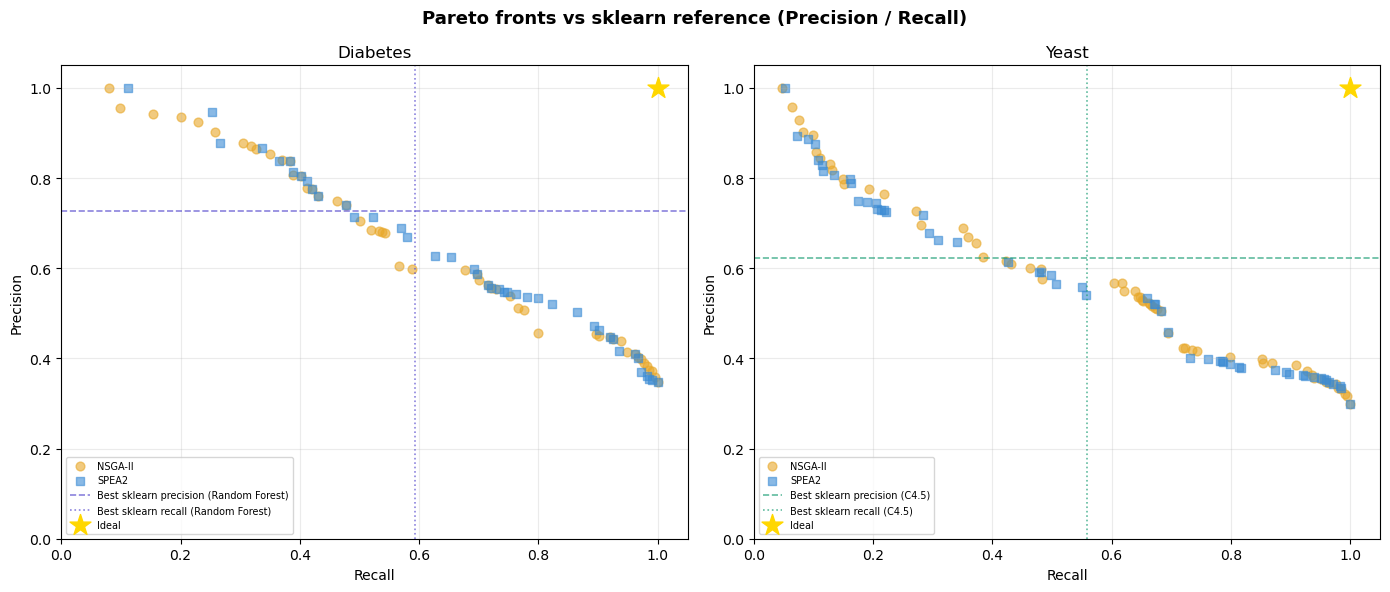

In [155]:
# GÉNÉRÉ PAR L'IA
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Pareto fronts vs sklearn reference (Precision / Recall)",
             fontsize=13, fontweight='bold')

for ax, dataset in zip(axes, DATASETS):
    # Plot Pareto fronts
    for algo_name, pareto_front in all_results[dataset].items():
        df_pf = pd.DataFrame([
            {"Recall":    -s.objectives[1],
             "Precision": -s.objectives[0],
             "F1":        -s.objectives[2]}
            for s in pareto_front
        ])
        ax.scatter(df_pf["Recall"], df_pf["Precision"],
                   color=COLORS[algo_name], alpha=0.6,
                   s=40, label=algo_name,
                   marker='o' if algo_name == 'NSGA-II' else 's')

    # Draw sklearn best-F1 reference lines
    subset = df_all[(df_all["Dataset"] == dataset) &
                    (df_all["Family"] == "Sklearn")]
    best_sklearn = subset.loc[subset["F1"].idxmax()]

    ax.axhline(best_sklearn["Precision"], color=COLORS[best_sklearn["Algorithm"]],
               linestyle='--', linewidth=1.2, alpha=0.7,
               label=f"Best sklearn precision ({best_sklearn['Algorithm']})")
    ax.axvline(best_sklearn["Recall"], color=COLORS[best_sklearn["Algorithm"]],
               linestyle=':', linewidth=1.2, alpha=0.7,
               label=f"Best sklearn recall ({best_sklearn['Algorithm']})")

    # Ideal point
    ax.scatter([1], [1], marker='*', s=250, color='gold', zorder=5, label='Ideal')

    ax.set_title(dataset)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("pareto_vs_sklearn.png", dpi=150)
plt.show()

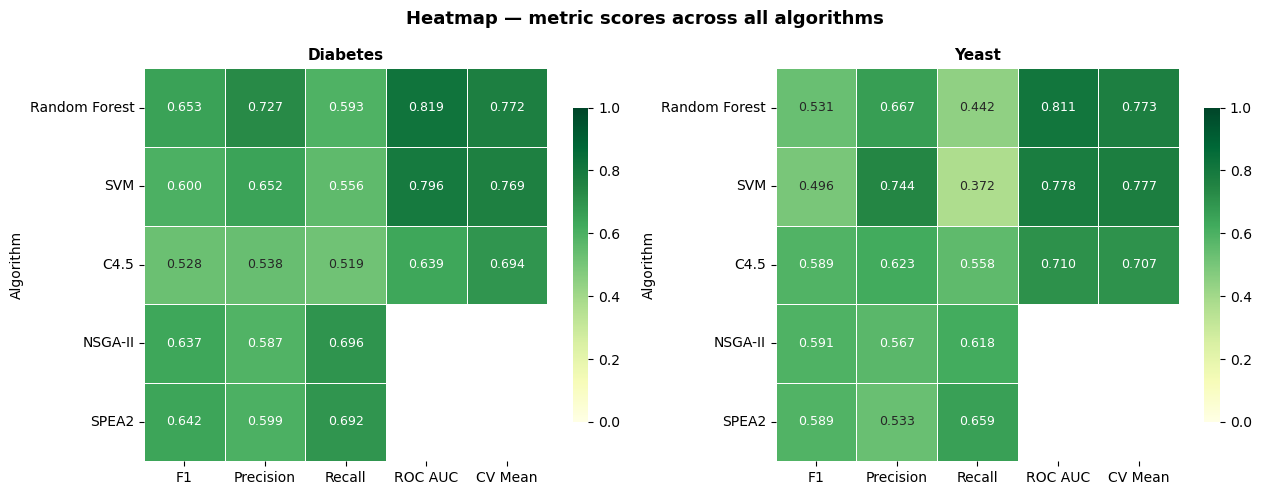

In [156]:
# GÉNÉRÉ PAR L'IA
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Heatmap — metric scores across all algorithms", fontsize=13, fontweight='bold')

metric_cols = ["F1", "Precision", "Recall", "ROC AUC", "CV Mean"]

for ax, dataset in zip(axes, DATASETS):
    subset = df_all[df_all["Dataset"] == dataset].set_index("Algorithm")
    matrix = subset.reindex(ALGO_ORDER)[metric_cols].astype(float)

    sns.heatmap(matrix, annot=True, fmt=".3f", cmap="YlGn",
                ax=ax, vmin=0, vmax=1,
                linewidths=0.5, cbar_kws={"shrink": 0.8},
                annot_kws={"size": 9})
    ax.set_title(dataset, fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("heatmap_all.png", dpi=150)
plt.show()